# Chapter 9. Multimodal


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import libraries

To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [4]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset

**EEG**

In [5]:
# load the Excel file as a DataFrame
eeg_data = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/Multimodal_dataset/EEG_dataset_multi.xlsx")
display(eeg_data.head())
print(eeg_data.shape)

,Fp 1_1-4,Fp 21-41_1-4,F 31_1-4,F 41_1-4,T 3_1-4,T 4_1-4,P 3_1-4,P 4_1-4,Fp 1_4-8,Fp 2_4-8,...,P 4_30-60,Fp 1_60-100,Fp 2_60-100,F 3_60-100,F 4_60-100,T 3_60-100,T 4_60-100,P 3_60-100,P 4_60-100,Label
0,44.349,46.945,37.492,32.753,22.9800,13.0830,23.720,21.065,12.1410,10.1610,...,10.8630,9.8838,11.432,10.7400,8.5359,16.6900,35.1230,7.5925,7.5649,0
1,224.370,164.310,58.853,49.023,25.4320,14.7730,36.308,34.064,18.5830,16.2200,...,3.2744,4.6473,10.692,1.4128,1.4728,2.5604,2.7126,1.3000,2.3577,0
2,29.330,30.016,28.656,29.415,10.9920,11.5410,19.566,21.606,13.7390,13.8240,...,5.1760,31.0290,27.361,13.9910,15.9950,15.2350,9.2711,4.9070,4.8101,0
3,43.769,37.034,19.918,21.243,9.4431,11.8860,14.643,17.040,7.1175,6.9619,...,7.6697,17.9940,26.876,10.1770,13.7680,15.2020,16.8880,6.9588,7.4308,0
4,83.756,93.963,30.643,33.137,15.9790,7.3685,19.426,16.880,10.1950,9.9554,...,18.7380,8.1048,12.665,7.0257,7.0204,9.7079,6.3175,8.3665,12.7210,0


(120, 57)


**ECG**

In [6]:
# load the Excel file as a DataFrame
ecg_data =pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/Multimodal_dataset/ECG_dataset_multi.xlsx")
display(ecg_data.head())
print(ecg_data.shape)

,Subject NO.,Mean HR (BPM),AVNN (ms),SDNN (ms),NN50 (beats),pNN50 (%),RMSSD (ms),LF (ms2),LF Norm (n.u.),HF (ms2),HF Norm (n.u.),LF/HF Ratio,Label
0,1,85.8474,698.9147,45.8957,46,10.7477,29.6913,412.1663,46.8523,467.3008,53.1197,0.8820,0
1,2,88.3727,678.9429,23.8804,0,0.0000,11.6837,314.3801,87.1339,46.3382,12.8431,6.7845,0
2,3,79.4924,754.7887,50.0888,71,17.4877,37.8050,612.5444,45.8684,722.3938,54.0941,0.8479,0
3,4,78.8327,761.1057,41.4575,27,6.4593,27.0164,446.1722,64.1144,249.5922,35.8661,1.7876,0
4,5,63.3055,947.7851,40.0863,54,16.0714,35.2921,367.0269,49.2067,378.3478,50.7245,0.9701,0


(120, 13)


**Connect data **

EEG and ECG data have an identical structure and are already summarized into features for each time interval (mean HR, standard deviation, low/high frequency range, etc.)—that is, they are not raw signals, but tabular features. This significantly simplifies multimodal fusion.

In [7]:
import pandas as pd



# Separate features and label
eeg_features = eeg_data.drop(columns=["Label"])
ecg_features = ecg_data.drop(columns=["Label"])

# Optional: rename columns to indicate modality
eeg_features = eeg_features.add_prefix("EEG_")
ecg_features = ecg_features.add_prefix("ECG_")

# Concatenate features side by side
X = pd.concat([eeg_features, ecg_features], axis=1)

# Use label from one of the datasets
y = eeg_data["Label"]

# Final multimodal dataset
multimodal_data = pd.concat([X, y], axis=1)

# Display the first rows
display(multimodal_data.head())
print("Shape of eeg_features dataset:", eeg_features.shape)
print("Shape of ecg_features dataset:", ecg_features.shape)
print("Shape of multimodal dataset:", multimodal_data.shape)


,EEG_Fp 1_1-4,EEG_Fp 21-41_1-4,EEG_F 31_1-4,EEG_F 41_1-4,EEG_T 3_1-4,EEG_T 4_1-4,EEG_P 3_1-4,EEG_P 4_1-4,EEG_Fp 1_4-8,EEG_Fp 2_4-8,...,ECG_SDNN (ms),ECG_NN50 (beats),ECG_pNN50 (%),ECG_RMSSD (ms),ECG_LF (ms2),ECG_LF Norm (n.u.),ECG_HF (ms2),ECG_HF Norm (n.u.),ECG_LF/HF Ratio,Label
0,44.349,46.945,37.492,32.753,22.9800,13.0830,23.720,21.065,12.1410,10.1610,...,45.8957,46,10.7477,29.6913,412.1663,46.8523,467.3008,53.1197,0.8820,0
1,224.370,164.310,58.853,49.023,25.4320,14.7730,36.308,34.064,18.5830,16.2200,...,23.8804,0,0.0000,11.6837,314.3801,87.1339,46.3382,12.8431,6.7845,0
2,29.330,30.016,28.656,29.415,10.9920,11.5410,19.566,21.606,13.7390,13.8240,...,50.0888,71,17.4877,37.8050,612.5444,45.8684,722.3938,54.0941,0.8479,0
3,43.769,37.034,19.918,21.243,9.4431,11.8860,14.643,17.040,7.1175,6.9619,...,41.4575,27,6.4593,27.0164,446.1722,64.1144,249.5922,35.8661,1.7876,0
4,83.756,93.963,30.643,33.137,15.9790,7.3685,19.426,16.880,10.1950,9.9554,...,40.0863,54,16.0714,35.2921,367.0269,49.2067,378.3478,50.7245,0.9701,0


Shape of eeg_features dataset: (120, 56)
Shape of ecg_features dataset: (120, 12)
Shape of multimodal dataset: (120, 69)


Scaling data

In [8]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Separate features and label
X = multimodal_data.drop(columns=["Label"])  # All columns except 'Label'
y = multimodal_data["Label"]                 # Keep labels unchanged

# Scale features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Recombine scaled features with original label
df_scaled = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# Save to a new CSV if needed
#df_scaled_eeg.to_csv("your_data_scaled.csv", index=False)

# Optional: display first rows

display(df_scaled.head())


,EEG_Fp 1_1-4,EEG_Fp 21-41_1-4,EEG_F 31_1-4,EEG_F 41_1-4,EEG_T 3_1-4,EEG_T 4_1-4,EEG_P 3_1-4,EEG_P 4_1-4,EEG_Fp 1_4-8,EEG_Fp 2_4-8,...,ECG_SDNN (ms),ECG_NN50 (beats),ECG_pNN50 (%),ECG_RMSSD (ms),ECG_LF (ms2),ECG_LF Norm (n.u.),ECG_HF (ms2),ECG_HF Norm (n.u.),ECG_LF/HF Ratio,Label
0,0.108620,0.119399,0.229835,0.195398,0.377757,0.141532,0.111066,0.074183,0.126563,0.096444,...,0.247939,0.199134,0.142163,0.222343,0.073558,0.419569,0.112227,0.580484,0.083244,0
1,0.635344,0.474981,0.395982,0.329160,0.428412,0.171114,0.198692,0.160698,0.233821,0.204365,...,0.083979,0.000000,0.000000,0.025720,0.054136,0.968369,0.006962,0.031402,0.794723,0
2,0.064676,0.068109,0.161109,0.167955,0.130099,0.114540,0.082149,0.077784,0.153169,0.161688,...,0.279167,0.307359,0.231314,0.310935,0.113355,0.406164,0.176015,0.593768,0.079134,0
3,0.106923,0.089372,0.093144,0.100770,0.098100,0.120579,0.047880,0.047395,0.042922,0.039462,...,0.214885,0.116883,0.085439,0.193136,0.080312,0.654749,0.057788,0.345269,0.192404,0
4,0.223921,0.261850,0.176564,0.198555,0.233124,0.041503,0.081175,0.046330,0.094162,0.092782,...,0.204673,0.233766,0.212581,0.283497,0.064593,0.451645,0.089984,0.547831,0.093863,0


**Mix Data EEG**

In [9]:
from sklearn.utils import shuffle


# Shuffle the entire DataFrame
data_mixed = shuffle(df_scaled, random_state=42).reset_index(drop=True)

# Check the result
display(data_mixed.head())


,EEG_Fp 1_1-4,EEG_Fp 21-41_1-4,EEG_F 31_1-4,EEG_F 41_1-4,EEG_T 3_1-4,EEG_T 4_1-4,EEG_P 3_1-4,EEG_P 4_1-4,EEG_Fp 1_4-8,EEG_Fp 2_4-8,...,ECG_SDNN (ms),ECG_NN50 (beats),ECG_pNN50 (%),ECG_RMSSD (ms),ECG_LF (ms2),ECG_LF Norm (n.u.),ECG_HF (ms2),ECG_HF Norm (n.u.),ECG_LF/HF Ratio,Label
0,0.049280,0.046096,0.160922,0.113028,0.195794,0.031352,0.081836,0.052000,0.040065,0.037161,...,0.192002,0.082251,0.068292,0.218516,0.067998,0.939524,0.012177,0.059029,0.666108,1
1,0.199630,0.221628,0.307561,0.385929,0.662187,0.443360,0.179020,0.163767,0.296591,0.342727,...,0.254455,0.099567,0.060006,0.181749,0.079147,0.669395,0.053979,0.329350,0.203385,1
2,0.223921,0.261850,0.176564,0.198555,0.233124,0.041503,0.081175,0.046330,0.094162,0.092782,...,0.204673,0.233766,0.212581,0.283497,0.064593,0.451645,0.089984,0.547831,0.093863,0
3,0.111054,0.133124,0.218907,0.253277,0.342285,0.363190,0.104940,0.078130,0.150805,0.223103,...,0.322547,0.021645,0.014408,0.139459,0.044580,0.437370,0.066981,0.562399,0.089006,1
4,0.063561,0.060326,0.122716,0.137627,0.270951,0.218236,0.134302,0.122988,0.157082,0.176258,...,0.285983,0.402597,0.295706,0.357173,0.139251,0.412937,0.210160,0.587112,0.081183,0


**Visualisation**

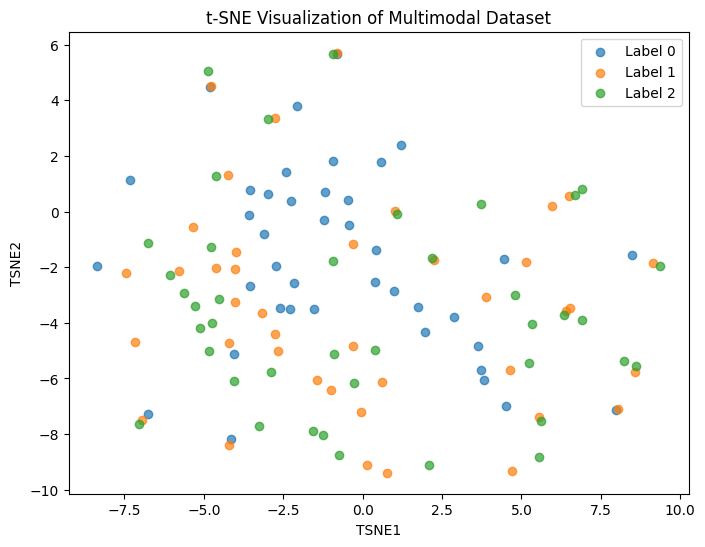

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Separate features and labels
#X = data_mixed.drop("Label", axis=1)
#y = data_mixed["Label"]

# Optional: scale features for t-SNE
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame with t-SNE results
tsne_df = pd.DataFrame()
tsne_df['TSNE1'] = X_tsne[:,0]
tsne_df['TSNE2'] = X_tsne[:,1]
tsne_df['Label'] = y

# Plot
plt.figure(figsize=(8,6))
for label in tsne_df['Label'].unique():
    subset = tsne_df[tsne_df['Label'] == label]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Label {label}', alpha=0.7)
plt.title("t-SNE Visualization of Multimodal Dataset")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.legend()
plt.show()


fgdfgf

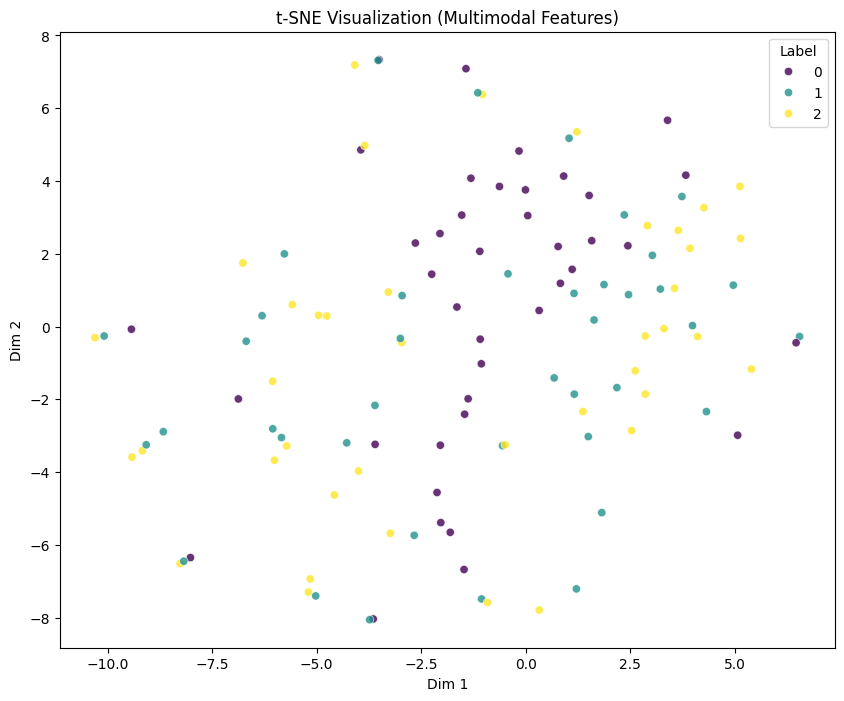

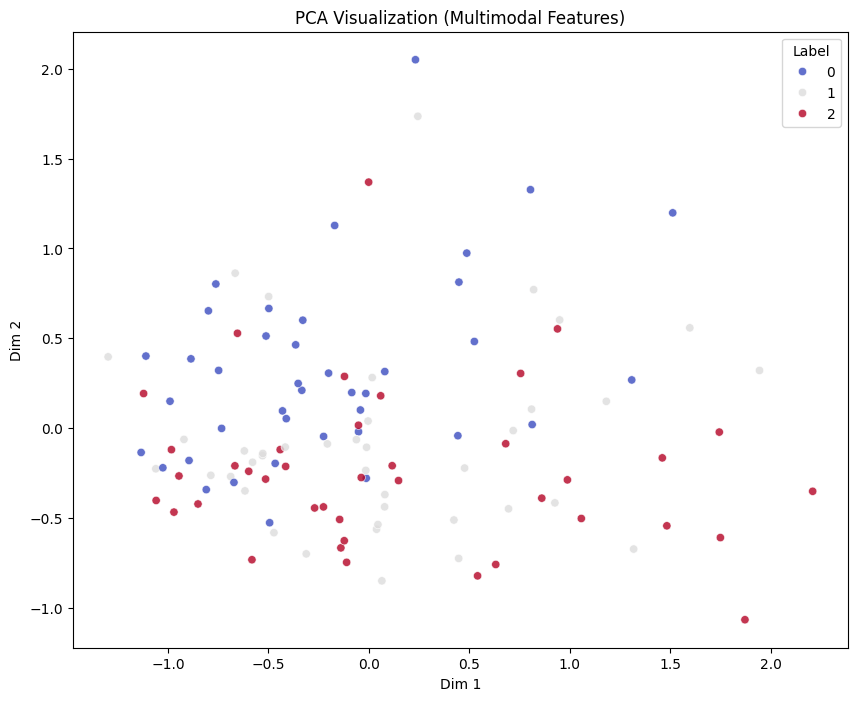

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


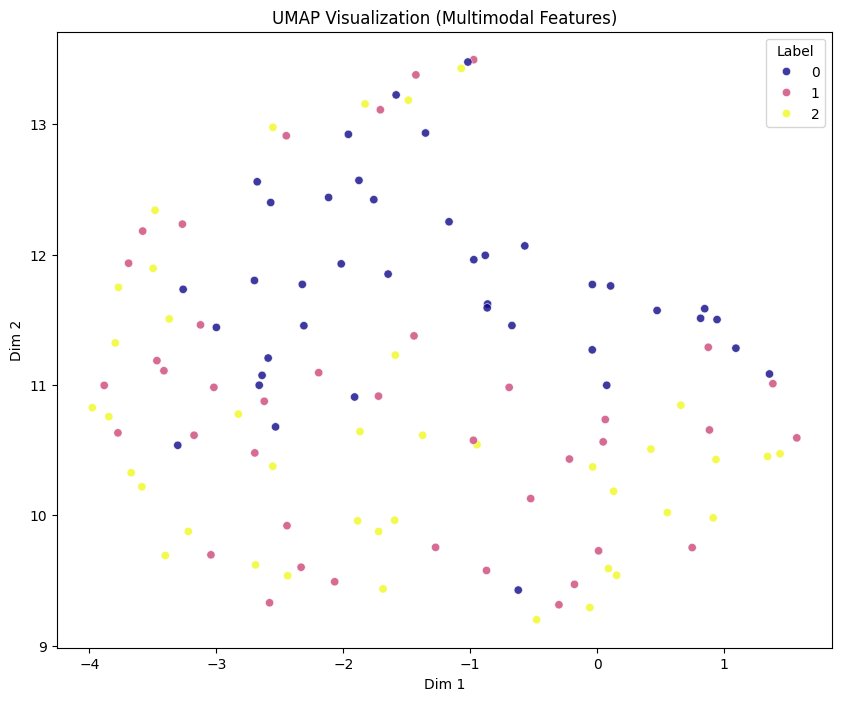

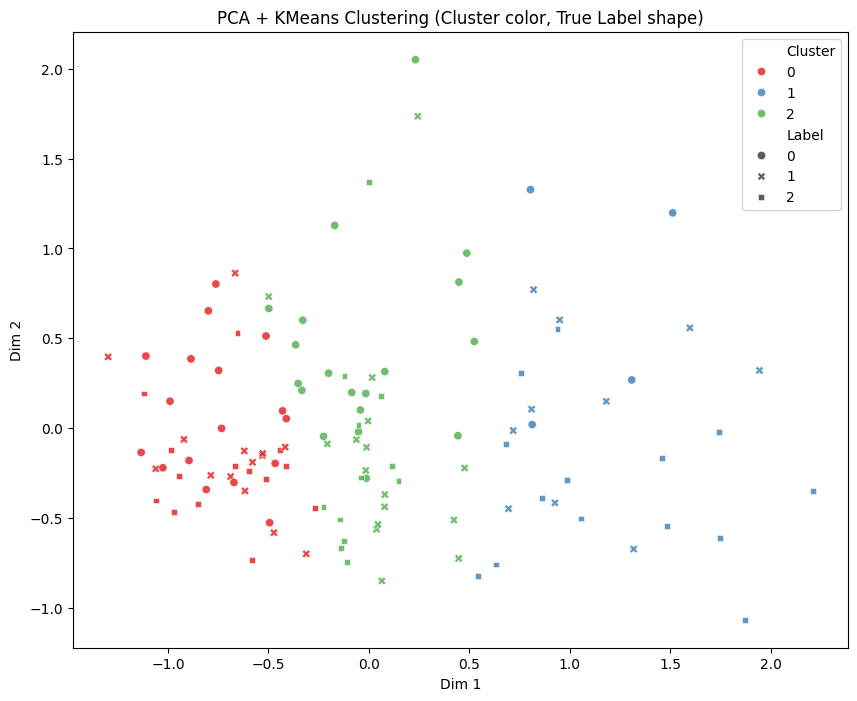

In [11]:
# =========================
# Multimodal (EEG + ECG) Data Visualization
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans

# -------------------------
# 1. Load your multimodal dataset
# -------------------------
# data_mixed should already have EEG + ECG features and 'Label' column
# If not, load CSV/Excel here
# data_mixed = pd.read_csv("multimodal_dataset.csv")

# -------------------------
# 2. Scale features (exclude label)
# -------------------------
features = data_mixed.drop('Label', axis=1)
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# -------------------------
# 3. Shuffle / mix data
# -------------------------
data_scaled = pd.DataFrame(features_scaled, columns=features.columns)
data_scaled['Label'] = data_mixed['Label'].values
data_scaled = data_scaled.sample(frac=1, random_state=42).reset_index(drop=True)

# Features and labels
X = data_scaled.drop('Label', axis=1)
y = data_scaled['Label']

# -------------------------
# 4a. t-SNE Visualization
# -------------------------
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
tsne_results = tsne.fit_transform(X)
tsne_df = pd.DataFrame(tsne_results, columns=['Dim 1', 'Dim 2'])
tsne_df['Label'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='Label', data=tsne_df, palette='viridis', alpha=0.8)
plt.title("t-SNE Visualization (Multimodal Features)")
plt.show()

# -------------------------
# 4b. PCA Visualization
# -------------------------
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_results, columns=['Dim 1', 'Dim 2'])
pca_df['Label'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='Label', data=pca_df, palette='coolwarm', alpha=0.8)
plt.title("PCA Visualization (Multimodal Features)")
plt.show()

# -------------------------
# 4c. UMAP Visualization
# -------------------------
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_results = umap_reducer.fit_transform(X)
umap_df = pd.DataFrame(umap_results, columns=['Dim 1', 'Dim 2'])
umap_df['Label'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='Label', data=umap_df, palette='plasma', alpha=0.8)
plt.title("UMAP Visualization (Multimodal Features)")
plt.show()

# -------------------------
# 5. Optional: KMeans clustering on PCA
# -------------------------
kmeans = KMeans(n_clusters=len(y.unique()), random_state=42)
clusters = kmeans.fit_predict(pca_results)
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='Cluster', data=pca_df, palette='Set1', style='Label', alpha=0.8)
plt.title("PCA + KMeans Clustering (Cluster color, True Label shape)")
plt.show()


**Machine Learning**

In [12]:
# Method A: Simple list
print(data_mixed.columns.tolist())

['EEG_Fp 1_1-4 ', 'EEG_Fp 21-41_1-4  ', 'EEG_F 31_1-4 ', 'EEG_F 41_1-4 ', 'EEG_T 3_1-4 ', 'EEG_T 4_1-4 ', 'EEG_P 3_1-4 ', 'EEG_P 4_1-4 ', 'EEG_Fp 1_4-8 ', 'EEG_Fp 2_4-8 ', 'EEG_F 3_4-8 ', 'EEG_F 4_4-8 ', 'EEG_T 3_4-8 ', 'EEG_T 4_4-8 ', 'EEG_P 3_4-8 ', 'EEG_P 4_4-8 ', 'EEG_Fp 1_8-12 ', 'EEG_Fp 2_8-12 ', 'EEG_F 3_8-12 ', 'EEG_F 4_8-12 ', 'EEG_T 3_8-12 ', 'EEG_T 4_8-12 ', 'EEG_P 3_8-12 ', 'EEG_P 4_8-12 ', 'EEG_Fp 1_12-20 ', 'EEG_Fp 2_12-20 ', 'EEG_F 3_12-20 ', 'EEG_F 4_12-20 ', 'EEG_T 3_12-20 ', 'EEG_T 4_12-20 ', 'EEG_P 3_12-20 ', 'EEG_P 4_12-20 ', 'EEG_Fp 1_20-30 ', 'EEG_Fp 2_20-30', 'EEG_F 3_20-30', 'EEG_F 4_20-30', 'EEG_T 3_20-30', 'EEG_T 4_20-30', 'EEG_P 3_20-30', 'EEG_P 4_20-30', 'EEG_Fp 1_30-60', 'EEG_Fp 2_30-60', 'EEG_F 3_30-60', 'EEG_F 4_30-60', 'EEG_T 3_30-60', 'EEG_T 4_30-60', 'EEG_P 3_30-60', 'EEG_P 4_30-60', 'EEG_Fp 1_60-100', 'EEG_Fp 2_60-100', 'EEG_F 3_60-100', 'EEG_F 4_60-100', 'EEG_T 3_60-100', 'EEG_T 4_60-100', 'EEG_P 3_60-100', 'EEG_P 4_60-100', 'ECG_Subject NO.', 'ECG_M

In [13]:
# =========================
# Multimodal (EEG + ECG) Random Forest Classification
# =========================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# -------------------------
# 1. Load multimodal dataset
# -------------------------
# data_mixed should already have EEG + ECG features and 'Label' column
# If not, load CSV/Excel here
# data_mixed = pd.read_csv("multimodal_dataset.csv")

# -------------------------
# 2. Scale features (exclude label)
# -------------------------
#features = data_mixed.drop('Label', axis=1)
#scaler = MinMaxScaler()
#features_scaled = scaler.fit_transform(features)

# Create DataFrame with scaled features
#features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
#features_scaled_df['Label'] = data_mixed['Label'].values

# -------------------------
# 3. Shuffle / mix data
# -------------------------
#features_scaled_df = features_scaled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# -------------------------
# 4. Separate features and target
# -------------------------
X = data_mixed.drop(['Label', 'ECG_Subject NO.'], axis=1)
y = data_mixed['Label']

#print(X)
#print(y)

# -------------------------
# 5. Train-test split (70% train, 30% test)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 6. Initialize Random Forest
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=45,   # number of trees
    max_depth=None,     # allow trees to expand fully
    random_state=42
)

# -------------------------
# 7. Train the model
# -------------------------
rf_model.fit(X_train, y_train)

# -------------------------
# 8. Make predictions
# -------------------------
y_pred = rf_model.predict(X_test)

# -------------------------
# 9. Evaluate the model
# -------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.33      0.25      0.29         8
           2       0.38      0.38      0.38         8

    accuracy                           0.50        24
   macro avg       0.47      0.50      0.48        24
weighted avg       0.47      0.50      0.48        24

Confusion Matrix:
[[7 0 1]
 [2 2 4]
 [1 4 3]]


**Naive Bayes**

In [14]:
# ========================================================
# Multimodal (EEG + ECG) Naive Bayes Classification
# ========================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
# --------------------------------------------------------
# We drop 'Label' and 'ECG_Subject NO.' to ensure we are testing
# biological patterns, not memorizing individual people.
X = data_mixed.drop(['Label', 'ECG_Subject NO.'], axis=1)
y = data_mixed['Label']

# 2. Scaling for Naive Bayes
# --------------------------------------------------------
# GaussianNB works best when data is standardized (Mean=0, Std=1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split (80% train, 20% test)
# --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and Train Naive Bayes
# --------------------------------------------------------
# GaussianNB is the standard version for continuous biological data.
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 5. Make Predictions
# --------------------------------------------------------
y_pred = nb_model.predict(X_test)

# 6. Evaluate the Model
# --------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Bayes Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Naive Bayes Test Accuracy: 0.4167

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         8
           1       0.29      0.25      0.27         8
           2       0.29      0.25      0.27         8

    accuracy                           0.42        24
   macro avg       0.39      0.42      0.40        24
weighted avg       0.39      0.42      0.40        24

Confusion Matrix:
[[6 1 1]
 [2 2 4]
 [2 4 2]]


KNN

In [15]:
# ========================================================
# Multimodal (EEG + ECG) K-Nearest Neighbors (KNN)
# ========================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
# --------------------------------------------------------
# Again, we drop 'ECG_Subject NO.' to ensure the model learns
# stress patterns, not individual ID numbers.
X = data_mixed.drop(['Label', 'ECG_Subject NO.'], axis=1)
y = data_mixed['Label']

# 2. Critical Scaling for KNN
# --------------------------------------------------------
# KNN is highly sensitive to the scale of data.
# StandardScaler is preferred here to normalize the distance metrics.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split
# --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and Train KNN
# --------------------------------------------------------
# n_neighbors=5 is standard, but you can tune this.
# weights='distance' gives more importance to closer neighbors.
knn_model = KNeighborsClassifier(n_neighbors=50, weights='distance')
knn_model.fit(X_train, y_train)

# 5. Make Predictions
# --------------------------------------------------------
y_pred = knn_model.predict(X_test)

# 6. Evaluate
# --------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

KNN Test Accuracy: 0.5417

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.88      0.64         8
           1       0.50      0.38      0.43         8
           2       0.75      0.38      0.50         8

    accuracy                           0.54        24
   macro avg       0.58      0.54      0.52        24
weighted avg       0.58      0.54      0.52        24



**SVM**

In [16]:
# ========================================================
# Multimodal (EEG + ECG) Support Vector Machine (SVM)
# ========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
# --------------------------------------------------------
X = data_mixed.drop(columns=['Label', 'ECG_Subject NO.'], errors='ignore')
y = data_mixed['Label']

# 2. Scaling (Mandatory for SVM)
# --------------------------------------------------------
# SVM calculates the margin based on distances; features must be standardized.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split
# --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Define the Parameter Grid for SVM
# --------------------------------------------------------
# C: Controls the trade-off between smooth boundary and classifying training points correctly.
# gamma: Defines how far the influence of a single training example reaches.
# kernel: 'rbf' is standard for non-linear biological signals.
param_grid = {
    'C': [0.1, 1, 10, 100, 200, 300],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'class_weight': ['balanced']
}

# 5. Initialize and Run Grid Search
# --------------------------------------------------------
svm_base = SVC(probability=True, random_state=42)

grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

print("Starting SVM Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# 6. Evaluate the Best SVM Model
# --------------------------------------------------------
best_svm = grid_search.best_estimator_
print(f"\nOptimal Parameters: {grid_search.best_params_}")

y_pred = best_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 30)
print(f"Final Optimized SVM Accuracy: {accuracy:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Starting SVM Hyperparameter Tuning...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Optimal Parameters: {'C': 100, 'class_weight': 'balanced', 'gamma': 0.001, 'kernel': 'rbf'}
------------------------------
Final Optimized SVM Accuracy: 0.5417
------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       0.40      0.25      0.31         8
           2       0.38      0.38      0.38         8

    accuracy                           0.54        24
   macro avg       0.50      0.54      0.51        24
weighted avg       0.50      0.54      0.51        24



**Hyper parameters**

In [17]:
# ========================================================
# Multimodal (EEG + ECG) Optimized Random Forest Pipeline
# ========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features and Labels
# --------------------------------------------------------
# We drop 'Label' (the target) and 'ECG_Subject NO.' (to prevent cheating/leakage)
# This leaves only the 140+ biological EEG and ECG features.
X = data_mixed.drop(columns=['Label', 'ECG_Subject NO.', 'Subject ID'], errors='ignore')
y = data_mixed['Label']

print(f"Total features identified for training: {X.shape[1]}")

# 2. Multimodal Scaling
# --------------------------------------------------------
# Scaling EEG and ECG together ensures all features are on the same mathematical scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Stratified Train/Test Split
# --------------------------------------------------------
# Stratify=y ensures the 3 stress classes are balanced in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Hyperparameter Search Grid
# --------------------------------------------------------
# Instead of guessing, we define a range of values for the computer to test.
param_grid = {
    'n_estimators': [100, 300, 500],      # Total number of trees
    'max_depth': [10, 20, None],          # Depth of trees (None = fully grown)
    'min_samples_split': [2, 5],          # Minimum samples to split a node
    'min_samples_leaf': [1, 2],           # Minimum samples in a leaf
    'max_features': ['sqrt'],             # Number of features per split
    'class_weight': ['balanced']          # Handles imbalance in stress classes
}

# 5. Initialize and Run Grid Search
# --------------------------------------------------------
rf_base = RandomForestClassifier(random_state=42)

# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

print("Starting Hyperparameter Optimization (Grid Search)...")
grid_search.fit(X_train, y_train)

# 6. Evaluate the Best Model
# --------------------------------------------------------
best_rf = grid_search.best_estimator_
print(f"\nOptimal Parameters: {grid_search.best_params_}")

y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 30)
print(f"Final Optimized Accuracy: {accuracy:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Feature Importance Analysis
# --------------------------------------------------------
# This helps verify which EEG/ECG features the model liked best
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print("\nTop 10 Most Important Biological Features:")
print(feat_imp_df.sort_values(by='Importance', ascending=False).head(10))

Total features identified for training: 67
Starting Hyperparameter Optimization (Grid Search)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Optimal Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
------------------------------
Final Optimized Accuracy: 0.3889
------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.92      0.69        12
           1       0.14      0.08      0.11        12
           2       0.22      0.17      0.19        12

    accuracy                           0.39        36
   macro avg       0.31      0.39      0.33        36
weighted avg       0.31      0.39      0.33        36


Top 10 Most Important Biological Features:
               Feature  Importance
8        EEG_Fp 1_4-8     0.038786
9        EEG_Fp 2_4-8     0.035301
64        ECG_HF (ms2)    0.02901

**Which hyper parameters were choosed**





In [18]:
# Print all hyperparameters of the trained Random Forest
params = rf_model.get_params()
for key, value in params.items():
    print(f"{key}: {value}")


bootstrap: True
ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 45
n_jobs: None
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [19]:
print("n_estimators:", rf_model.n_estimators)
print("max_depth:", rf_model.max_depth)
print("min_samples_split:", rf_model.min_samples_split)
print("min_samples_leaf:", rf_model.min_samples_leaf)
print("max_features:", rf_model.max_features)
print("class_weight:", rf_model.class_weight)


n_estimators: 45
max_depth: None
min_samples_split: 2
min_samples_leaf: 1
max_features: sqrt
class_weight: None


**Feature analasy**

/tmp/ipython-input-1367865555.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp_df.head(top_n), palette='viridis')


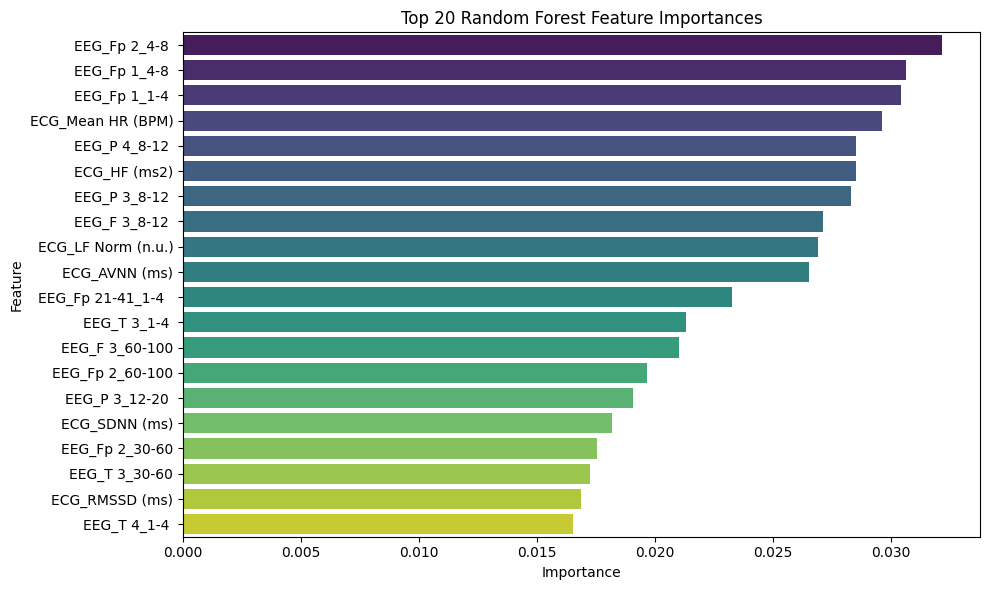

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort by importance descending
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# Plot top 20 features
top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(top_n), palette='viridis')
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**`Cross Validation`**

In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("5-Fold CV Accuracy:", scores)
print("Mean CV Accuracy:", scores.mean())


5-Fold CV Accuracy: [0.375      0.45833333 0.33333333 0.29166667 0.375     ]
Mean CV Accuracy: 0.36666666666666664


**Deep Learning**

**Costum CNN**

In [22]:
# =========================
# Multimodal (EEG + ECG) Deep Learning Classification
# =========================

# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Prepare Multimodal Features and Labels
# -----------------------------
# Assuming data_mixed is your preprocessed multimodal DataFrame
# with EEG + ECG features and 'Label' column

# Features (X) → drop 'Label'
X = data_mixed.drop(columns=['Label'], errors='ignore').values

# Labels (y)
y = data_mixed['Label'].values  # numeric labels, e.g., 0,1,2

# One-hot encode labels for deep learning
num_classes = len(np.unique(y))  # e.g., 3
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features to 0-1
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 4. Build Deep Learning Model
# -----------------------------
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(num_classes, activation='softmax')  # output layer for stress classes
])

# -----------------------------
# 5. Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 6. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 7. Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 8. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,035 (78.26 KB)

 Trainable params: 19,651 (76.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3510 - loss: 1.5058 - val_accuracy: 0.4706 - val_loss: 1.0610
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3123 - loss: 1.2929 - val_accuracy: 0.5294 - val_loss: 1.0599
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5155 - loss: 1.0361 - val_accuracy: 0.6471 - val_loss: 1.0626
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5460 - loss: 0.9666 - val_accuracy: 0.5882 - val_loss: 1.0659
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6337 - loss: 0.8592 - val_accuracy: 0.4706 - val_loss: 1.0716
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6142 - loss: 0.9183 - val_accuracy: 0.4706 - val_loss: 1.0823
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6636 - loss: 0.7822 - val_accuracy: 0.4118 - val_loss: 1.0918
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6192 - loss: 0.7717 - val_accuracy: 0.3529 - val_loss: 1.1023
Ep

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


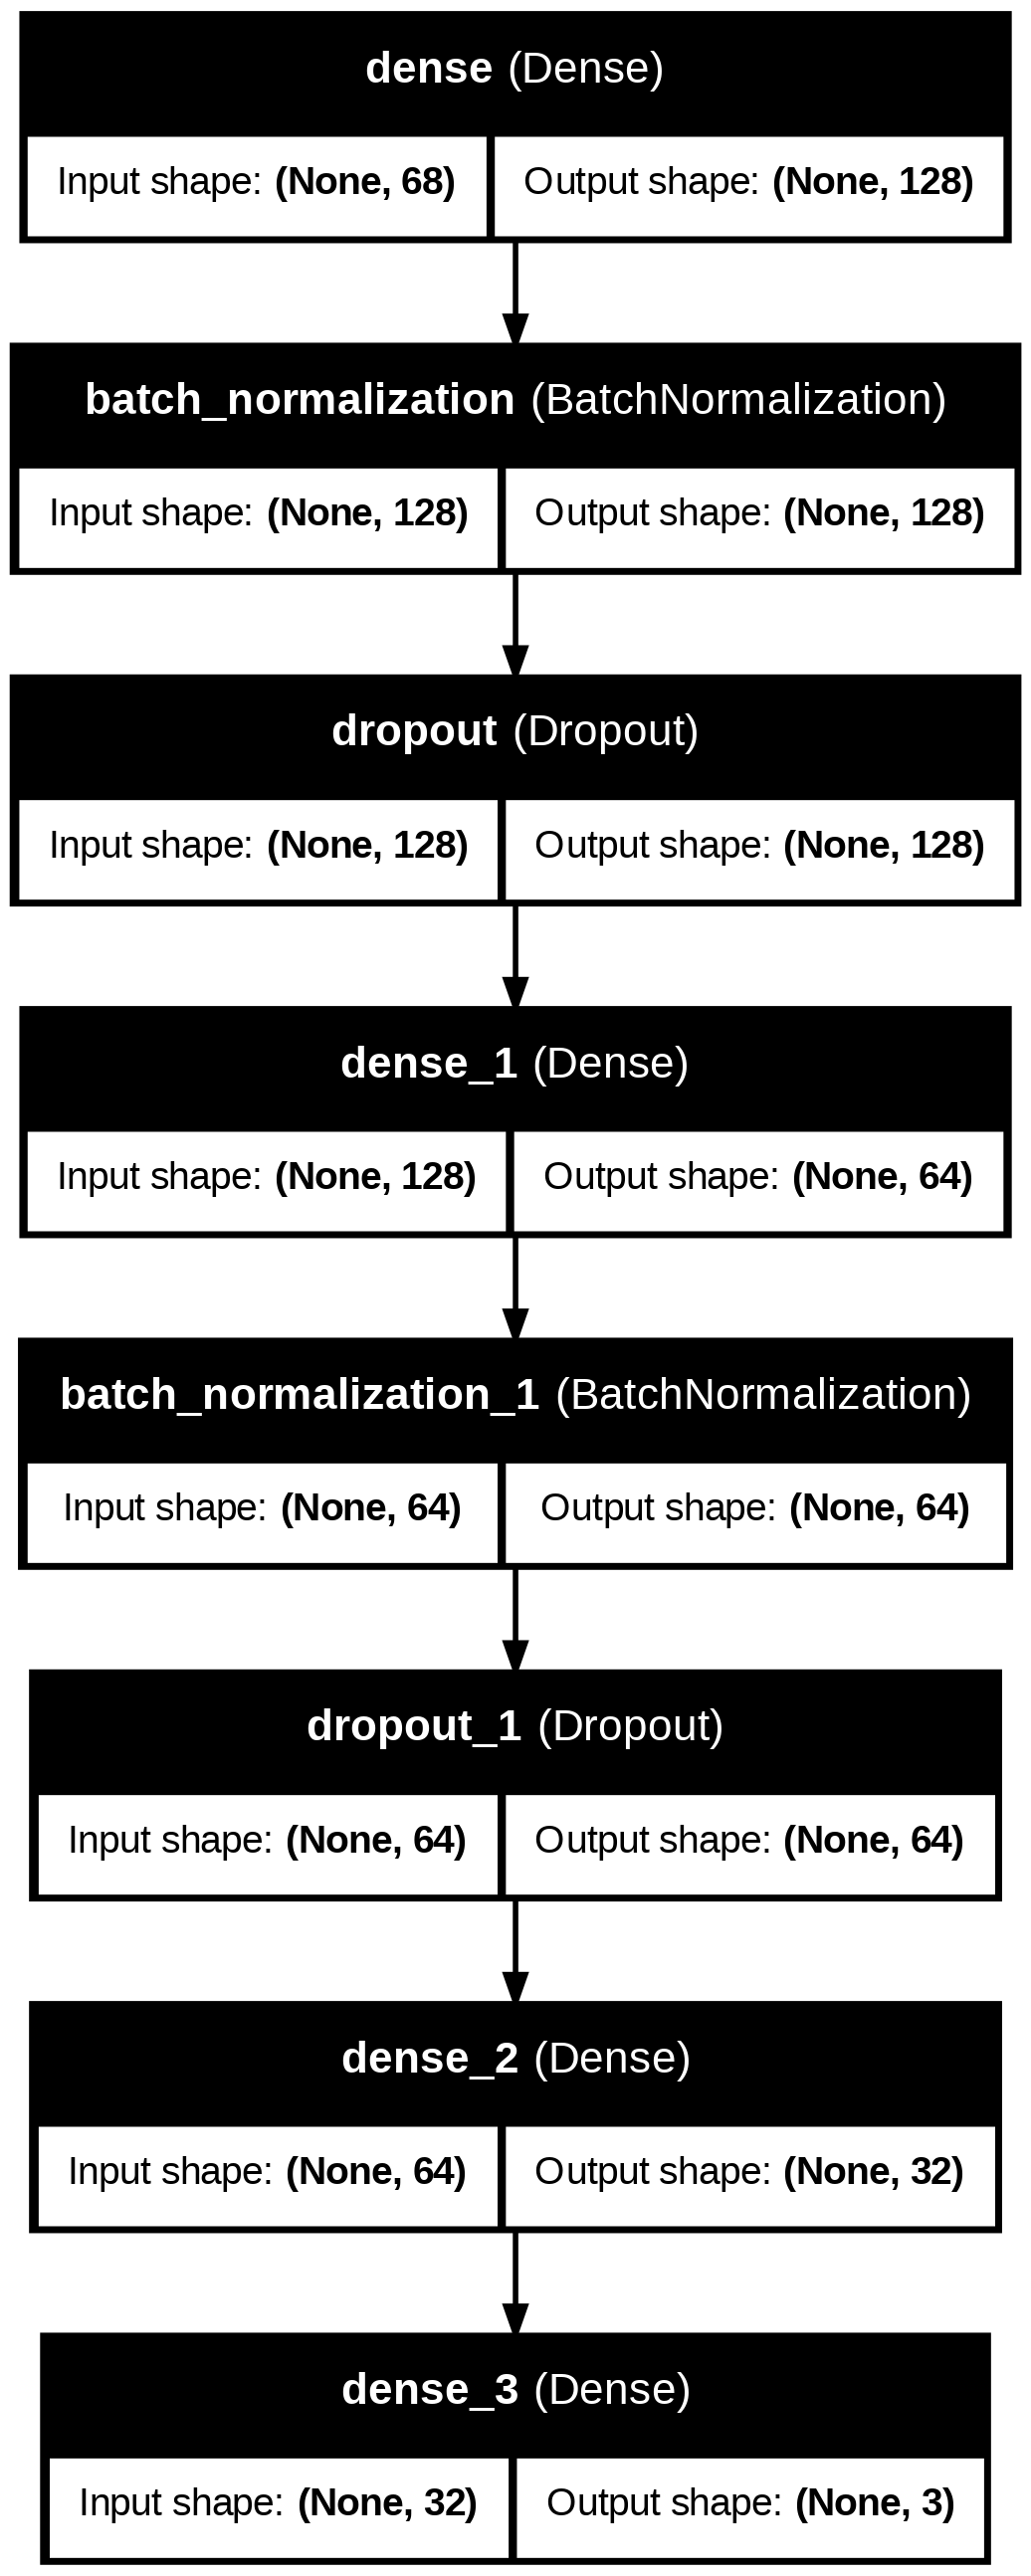

In [23]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True
)


**Hyper parameters**

In [24]:
# =========================
# Multimodal (EEG + ECG) Deep Learning Classification with Hyperparameters
# =========================

# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Hyperparameters
# -----------------------------
HYPERPARAMS = {
    "dense_units": [128, 64, 32],   # units per Dense layer
    "dropout_rates": [0.3, 0.3],    # dropout after first two Dense layers
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 0.001          # Adam optimizer learning rate
}

# -----------------------------
# 3. Prepare Multimodal Features and Labels
# -----------------------------
# Assuming data_mixed is your preprocessed multimodal DataFrame
# with EEG + ECG features and 'Label' column

# Features (X) → drop 'Label'
X = data_mixed.drop(columns=['Label'], errors='ignore').values

# Labels (y)
y = data_mixed['Label'].values  # numeric labels, e.g., 0,1,2

# One-hot encode labels for deep learning
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features to 0-1
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 4. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 5. Build Deep Learning Model
# -----------------------------
model = Sequential()

# First Dense layer
model.add(Dense(HYPERPARAMS["dense_units"][0], activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][0]))

# Second Dense layer
model.add(Dense(HYPERPARAMS["dense_units"][1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][1]))

# Third Dense layer
model.add(Dense(HYPERPARAMS["dense_units"][2], activation='relu'))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# -----------------------------
# 6. Compile Model
# -----------------------------
optimizer = Adam(learning_rate=HYPERPARAMS["learning_rate"])
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 7. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 8. Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 9. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,035 (78.26 KB)

 Trainable params: 19,651 (76.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2739 - loss: 1.7579 - val_accuracy: 0.1176 - val_loss: 1.1505
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4316 - loss: 1.5192 - val_accuracy: 0.1176 - val_loss: 1.1441
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3666 - loss: 1.4129 - val_accuracy: 0.1176 - val_loss: 1.1376
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4543 - loss: 1.2568 - val_accuracy: 0.1176 - val_loss: 1.1321
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4352 - loss: 1.1926 - val_accuracy: 0.1176 - val_loss: 1.1231
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5382 - loss: 1.0993 - val_accuracy: 0.1176 - val_loss: 1.1172
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4700 - loss: 1.0334 - val_accuracy: 0.2353 - val_loss: 1.1087
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6377 - loss: 0.8684 - val_accuracy: 0.2941 - val_loss: 1.1006
Ep

**Validation**

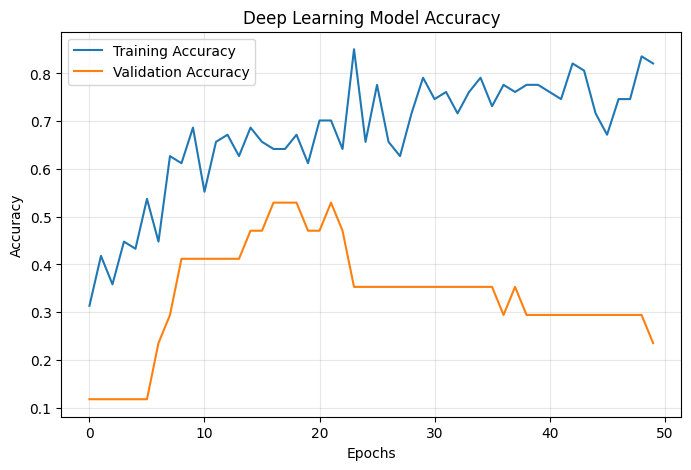

In [25]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Deep Learning Model Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**When accuracy is high **




In [26]:
# =========================
# Multimodal (EEG + ECG) Deep Learning Classification with Early Stopping
# =========================

# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Hyperparameters
# -----------------------------
HYPERPARAMS = {
    "dense_units": [128, 64, 32],   # units per Dense layer
    "dropout_rates": [0.3, 0.3],    # dropout after first two Dense layers
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 0.001,         # Adam optimizer learning rate
    "stop_val_acc": 0.99            # stop training if val_accuracy exceeds this
}

# -----------------------------
# 3. Prepare Multimodal Features and Labels
# -----------------------------
# data_mixed is your preprocessed multimodal DataFrame (EEG + ECG features) with 'Label' column
X = data_mixed.drop(columns=['Label'], errors='ignore').values
y = data_mixed['Label'].values  # numeric labels, e.g., 0,1,2
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features to 0-1
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 4. Build Deep Learning Model
# -----------------------------
model = Sequential()
model.add(Dense(HYPERPARAMS["dense_units"][0], activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][0]))

model.add(Dense(HYPERPARAMS["dense_units"][1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][1]))

model.add(Dense(HYPERPARAMS["dense_units"][2], activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(learning_rate=HYPERPARAMS["learning_rate"])
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -----------------------------
# 5. Custom Callback to Stop on Validation Accuracy
# -----------------------------
class StopOnValAccuracy(Callback):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc:
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
            if val_acc >= self.threshold:
                print(f"\nValidation accuracy {val_acc:.4f} reached threshold {self.threshold}. Stopping training.")
                self.model.stop_training = True

stop_callback = StopOnValAccuracy(threshold=HYPERPARAMS["stop_val_acc"])

# -----------------------------
# 6. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    validation_split=0.2,
    verbose=1,
    callbacks=[stop_callback]
)

print(f"\nHighest Validation Accuracy Achieved: {stop_callback.best_val_acc:.4f}")

# -----------------------------
# 7. Evaluate Model on Test Set
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 8. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,035 (78.26 KB)

 Trainable params: 19,651 (76.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2558 - loss: 1.6926 - val_accuracy: 0.3529 - val_loss: 1.1006
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2441 - loss: 1.4506 - val_accuracy: 0.4118 - val_loss: 1.0999
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3055 - loss: 1.4356 - val_accuracy: 0.2353 - val_loss: 1.1028
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4046 - loss: 1.3523 - val_accuracy: 0.1765 - val_loss: 1.1056
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4689 - loss: 1.0504 - val_accuracy: 0.1765 - val_loss: 1.1069
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4845 - loss: 1.0122 - val_accuracy: 0.1176 - val_loss: 1.1080
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4700 - loss: 1.0569 - val_accuracy: 0.1176 - val_loss: 1.1096
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5414 - loss: 0.9457 - val_accuracy: 0.1176 - val_loss: 1.1117
Ep

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.33      0.50        12
     NEUTRAL       0.00      0.00      0.00        12
    POSITIVE       0.39      1.00      0.56        12

    accuracy                           0.44        36
   macro avg       0.46      0.44      0.35        36
weighted avg       0.46      0.44      0.35        36


Confusion Matrix:
[[ 4  1  7]
 [ 0  0 12]
 [ 0  0 12]]


**LSTM**

In [27]:
# =========================
# Multimodal (EEG + ECG) LSTM Classification with Early Stopping
# =========================

# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Hyperparameters
# -----------------------------
HYPERPARAMS = {
    "lstm_units": [128, 64],
    "dense_units": 32,
    "dropout_rates": [0.3, 0.3],
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 0.001,
    "stop_val_acc": 0.99
}

# -----------------------------
# 3. Prepare Multimodal Features and Labels
# -----------------------------
# data_mixed contains EEG + ECG features and 'Label'

X = data_mixed.drop(columns=['Label'], errors='ignore').values
y = data_mixed['Label'].values  # numeric labels: 0,1,2

num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 4. Reshape for LSTM
# -----------------------------
# Treat each feature as a timestep
# Shape: (samples, timesteps, channels)
X = X.reshape((X.shape[0], X.shape[1], 1))

# -----------------------------
# 5. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# 6. Custom Callback (Early Stop on Validation Accuracy)
# -----------------------------
class StopOnValAccuracy(Callback):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc:
            self.best_val_acc = max(self.best_val_acc, val_acc)
            if val_acc >= self.threshold:
                print(
                    f"\nValidation accuracy {val_acc:.4f} "
                    f"reached threshold {self.threshold}. Stopping training."
                )
                self.model.stop_training = True

stop_callback = StopOnValAccuracy(HYPERPARAMS["stop_val_acc"])

# -----------------------------
# 7. Build LSTM Model
# -----------------------------
model = Sequential()

# First LSTM layer
model.add(
    LSTM(
        HYPERPARAMS["lstm_units"][0],
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)
model.add(Dropout(HYPERPARAMS["dropout_rates"][0]))

# Second LSTM layer
model.add(LSTM(HYPERPARAMS["lstm_units"][1]))
model.add(Dropout(HYPERPARAMS["dropout_rates"][1]))

# Dense layers
model.add(Dense(HYPERPARAMS["dense_units"], activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# -----------------------------
# 8. Compile Model
# -----------------------------
optimizer = Adam(learning_rate=HYPERPARAMS["learning_rate"])
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 9. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    validation_split=0.2,
    verbose=1,
    callbacks=[stop_callback]
)

print(f"\nHighest Validation Accuracy Achieved: {stop_callback.best_val_acc:.4f}")

# -----------------------------
# 10. Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 11. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 68, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 68, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,147 (461.51 KB)

 Trainable params: 118,147 (461.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.3009 - loss: 1.0976 - val_accuracy: 0.1176 - val_loss: 1.1144
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4089 - loss: 1.0893 - val_accuracy: 0.1176 - val_loss: 1.1320
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4011 - loss: 1.0843 - val_accuracy: 0.1176 - val_loss: 1.1565
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3702 - loss: 1.0822 - val_accuracy: 0.1176 - val_loss: 1.2159
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3780 - loss: 1.1052 - val_accuracy: 0.1176 - val_loss: 1.2237
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4089 - loss: 1.0853 - val_accuracy: 0.1176 - val_loss: 1.2210
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4128 - loss: 1.0648 - val_accuracy: 0.1176 - val_loss: 1.1885
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3737 - loss: 1.0823 - val_accuracy: 0.1176 - val_loss: 1.1756

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1, 68, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 1, 68, 8)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1, 68, 8)       │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 68, 16)      │            16 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1, 68, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 68, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 17, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 17, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 17, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 17, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 17, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 2, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,299 (5.07 KB)

 Trainable params: 1,219 (4.76 KB)

 Non-trainable params: 80 (320.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2743 - loss: 1.1637 - val_accuracy: 0.4118 - val_loss: 1.0975
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5421 - loss: 1.0261 - val_accuracy: 0.2941 - val_loss: 1.0988
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3972 - loss: 1.1444 - val_accuracy: 0.2941 - val_loss: 1.0990
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4238 - loss: 1.0533 - val_accuracy: 0.4706 - val_loss: 1.0989
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4274 - loss: 1.1252 - val_accuracy: 0.4706 - val_loss: 1.0987
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5236 - loss: 0.9953 - val_accuracy: 0.4706 - val_loss: 1.0984
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3922 - loss: 1.0650 - val_accuracy: 0.4706 - val_loss: 1.0983
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4085 - loss: 1.1227 - val_accuracy: 0.4706 - val_loss: 1.0986
E

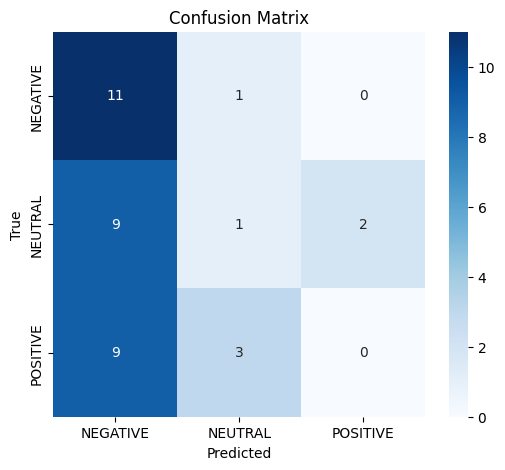

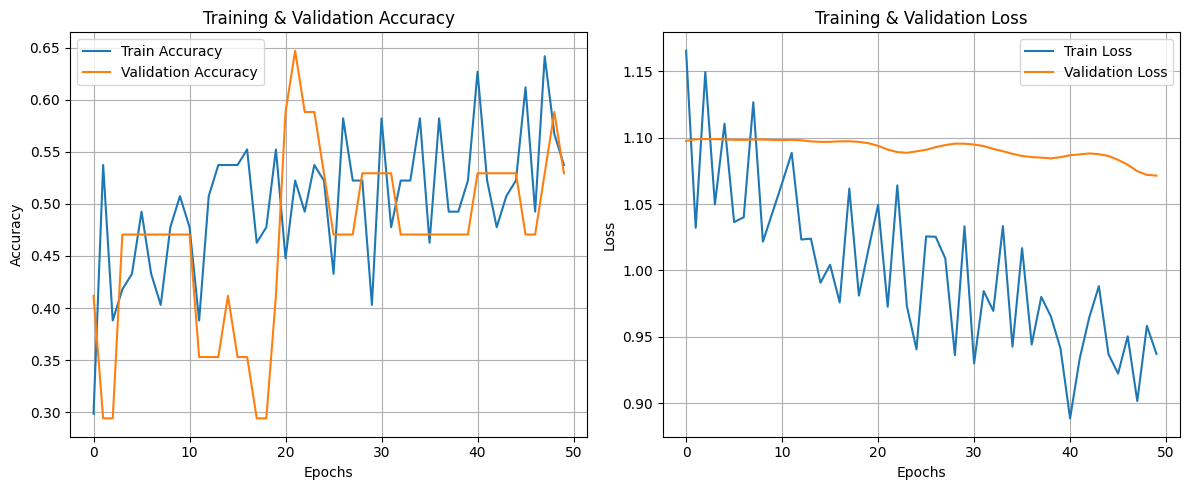

In [28]:
# =========================
# Multimodal (EEG + ECG) Deep Learning Classification with EEGNet
# =========================

# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 2. Prepare Multimodal Features and Labels
# -----------------------------
# Assuming data_mixed is your preprocessed DataFrame with EEG + ECG features and 'Label' column
X = data_mixed.drop(columns=['Label'], errors='ignore').values
y = data_mixed['Label'].values  # numeric labels, e.g., 0,1,2

# One-hot encode labels
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features to 0-1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 4. Reshape Data for EEGNet
# -----------------------------
# EEGNet expects 4D input: (samples, channels, time_steps, 1)
# For feature vectors, treat features as time_steps, and use 1 channel
n_channels = 1
n_samples = X_train.shape[1]

X_train_reshaped = X_train.reshape(-1, n_channels, n_samples, 1)
X_test_reshaped = X_test.reshape(-1, n_channels, n_samples, 1)

# -----------------------------
# 5. Define EEGNet Model
# -----------------------------
def EEGNet(nb_classes, Chans=1, Samples=128, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16):
    input1 = layers.Input((Chans, Samples, 1))

    # Temporal Convolution
    block1 = layers.Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    block1 = layers.BatchNormalization()(block1)

    # Depthwise Convolution (Spatial Filtering)
    block1 = layers.DepthwiseConv2D((Chans, 1), use_bias=False,
                                    depth_multiplier=D,
                                    depthwise_constraint=tf.keras.constraints.max_norm(1.))(block1)
    block1 = layers.BatchNormalization()(block1)
    block1 = layers.Activation('elu')(block1)
    block1 = layers.AveragePooling2D((1, 4))(block1)
    block1 = layers.Dropout(dropoutRate)(block1)

    # Separable Convolution
    block2 = layers.SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(block1)
    block2 = layers.BatchNormalization()(block2)
    block2 = layers.Activation('elu')(block2)
    block2 = layers.AveragePooling2D((1, 8))(block2)
    block2 = layers.Dropout(dropoutRate)(block2)

    flatten = layers.Flatten()(block2)
    dense = layers.Dense(nb_classes, activation='softmax')(flatten)

    return models.Model(inputs=input1, outputs=dense)

# -----------------------------
# 6. Build and Compile Model
# -----------------------------
model = EEGNet(nb_classes=num_classes, Chans=n_channels, Samples=n_samples, dropoutRate=0.3)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -----------------------------
# 7. Train Model
# -----------------------------
history = model.fit(
    X_train_reshaped, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 8. Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 9. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test_reshaped)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# -----------------------------
# 10. Plot Training Accuracy & Loss
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Advanced Data Preparation
# -----------------------------
# This keeps ALL 147 features EXCEPT the Label and ID numbers.
# We remove IDs because a Neural Network tries to find math patterns in
# "Subject 1, Subject 2," which isn't real biological data.
X = data_mixed.drop(columns=['Label', 'ECG_Subject NO.', 'Subject ID'], errors='ignore')
y = data_mixed['Label'].values

print(f"Total features being used for training: {X.shape[1]}")

# Use StandardScaler: It scales features to have a mean of 0 and variance of 1.
# This is crucial for EEG power bands (Delta/Gamma) which have very different scales.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encoding for the 3 stress classes (Baseline, Low, High)
num_classes = len(np.unique(y))
y_cat = tf.keras.utils.to_categorical(y, num_classes)

# Split 80/20. 'stratify=y' ensures the stress levels are balanced in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 2. The "Deep-Feature" Architecture
# -----------------------------
# This model is designed to handle 140+ features by starting wide and narrowing down.
model = models.Sequential([
    # Input Layer (Takes all 144+ features)
    layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3), # Prevents overfitting

    # Hidden Layer 1
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 2
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    # Hidden Layer 3
    layers.Dense(64, activation='relu'),

    # Output Layer (3 units for the 3 stress categories)
    layers.Dense(num_classes, activation='softmax')
])

# -----------------------------
# 3. Compilation & Training
# -----------------------------
# Using a smaller learning rate (0.0001) helps the model find the "sweet spot"
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping stops training if the model stops improving, saving the best version.
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# 4. Results
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final DL Accuracy: {test_acc:.4f}")

# Generate Predictions for the Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nDetailed Performance Report:")
print(classification_report(y_true, y_pred))

Total features being used for training: 67
Starting training...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2592 - loss: 1.5402 - val_accuracy: 0.2667 - val_loss: 1.1512
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3447 - loss: 1.4929 - val_accuracy: 0.2667 - val_loss: 1.1469
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4761 - loss: 1.2549 - val_accuracy: 0.2667 - val_loss: 1.1432
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3447 - loss: 1.2893 - val_accuracy: 0.2667 - val_loss: 1.1427
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3414 - loss: 1.2627 - val_accuracy: 0.2667 - val_loss: 1.1427
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4553 - loss: 1.0473 - val_accuracy: 0.2667 - val_loss: 1.1422
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4550 - loss: 1.1951 - val_accuracy: 0.2667 - val_loss: 1.1412
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4381 - loss: 1.2597 - val_accuracy: 0.2667 - val_loss: 1.1409
Epoch 

**LSTM**

In [30]:
# ========================================================
# Multimodal (EEG + ECG) LSTM Classification
# ========================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features
# --------------------------------------------------------
X = data_mixed.drop(columns=['Label', 'ECG_Subject NO.'], errors='ignore')
y = data_mixed['Label'].values

# Scaling is mandatory for LSTMs to prevent gradient explosion
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Reshape for LSTM [Samples, Time Steps, Features]
# --------------------------------------------------------
# Since your data is pre-extracted features, we treat each row as 1 time step.
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

num_classes = len(np.unique(y))
y_cat = tf.keras.utils.to_categorical(y, num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_cat, test_size=0.2, random_state=42, stratify=y
)

# 3. Build LSTM Architecture
# --------------------------------------------------------
model = models.Sequential([
    # First LSTM layer
    layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    layers.Dropout(0.2),

    # Second LSTM layer
    layers.LSTM(32),
    layers.Dropout(0.2),

    # Dense classifier
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# 4. Compile and Train
# --------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping to find the best accuracy
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate
# --------------------------------------------------------
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"\n✅ LSTM Test Accuracy: {test_acc:.4f}")

Training LSTM...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.3468 - loss: 1.1033 - val_accuracy: 0.5000 - val_loss: 1.0949
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3900 - loss: 1.0955 - val_accuracy: 0.5500 - val_loss: 1.0950
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5249 - loss: 1.0902 - val_accuracy: 0.5500 - val_loss: 1.0958
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4334 - loss: 1.0897 - val_accuracy: 0.4500 - val_loss: 1.0965
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5968 - loss: 1.0825 - val_accuracy: 0.5000 - val_loss: 1.0970
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5720 - loss: 1.0771 - val_accuracy: 0.5000 - val_loss: 1.0967
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5746 - loss: 1.0681 - val_accuracy: 0.4500 - val_loss: 1.0963
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5929 - loss: 1.0608 - val_accuracy: 0.4000 - val_loss: 1.0957
Epo

Search of layers

In [31]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.2 MB/s eta 0:00:00


In [32]:
import keras_tuner as kt
from tensorflow import keras

# 1. Define a "HyperModel" function
# --------------------------------------------------------
def build_model(hp):
    model = keras.Sequential()

    # Tune the number of LSTM layers (Search between 1 and 3 layers)
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.LSTM(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            return_sequences=True if i < hp.Int('num_layers', 1, 3) - 1 else False,
            input_shape=(X_train.shape[1], X_train.shape[2])
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))

    # Tune the number of units in the Dense layer
    model.add(layers.Dense(
        units=hp.Int('dense_units', 16, 64, step=16),
        activation='relu'
    ))

    model.add(layers.Dense(num_classes, activation='softmax'))

    # Tune the learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. Initialize the Tuner (RandomSearch or BayesianOptimization)
# --------------------------------------------------------
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # How many different architectures to try
    executions_per_trial=1,
    directory='my_dir',
    project_name='lstm_tuning'
)

# 3. Run the search
# --------------------------------------------------------
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

# 4. Get the best model
# --------------------------------------------------------
best_model = tuner.get_best_models(num_models=1)[0]
print("\n--- Best Architecture Found ---")
best_model.summary()

Trial 10 Complete [00h 00m 09s]
val_accuracy: 0.5

Best val_accuracy So Far: 0.550000011920929
Total elapsed time: 00h 01m 57s

--- Best Architecture Found ---


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │       100,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 254,275 (993.26 KB)

 Trainable params: 254,275 (993.26 KB)

 Non-trainable params: 0 (0.00 B)

**Keras Tuner for standarnt CNN**

In [36]:
import numpy as np
import pandas as pd
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Data Preparation & Strict Reshaping
# --------------------------------------------------------
# Assuming 'data_mixed' is your original DataFrame
X = data_mixed.drop(columns=['Label', 'ECG_Subject NO.'], errors='ignore').values
y = data_mixed['Label'].values

# Standardize features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode the labels for 'categorical_crossentropy'
# This turns labels [0, 1, 2] into vectors like [1, 0, 0]
y_encoded = to_categorical(y, num_classes=3)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y
)

# FIXED RESHAPE: Force shape to (Samples, 67, 1)
# The -1 tells numpy to calculate the number of samples automatically.
X_train_cnn = X_train.reshape(-1, 67, 1)
X_test_cnn = X_test.reshape(-1, 67, 1)

print(f"Final Input Shape for CNN: {X_train_cnn.shape}")

# 2. Define the CNN HyperModel
# --------------------------------------------------------
def build_cnn_model(hp):
    model = keras.Sequential()

    # Input Layer: Explicitly 67 features, 1 channel
    model.add(layers.Input(shape=(67, 1)))

    # Tune the number of Convolutional Layers (1 to 3)
    for i in range(hp.Int('num_conv_layers', 1, 3)):
        model.add(layers.Conv1D(
            filters=hp.Int(f'filters_{i}', 32, 128, step=32),
            kernel_size=3,  # Fixed size 3 to ensure we don't out-shrink the data
            activation='relu',
            padding='same'
        ))
        model.add(layers.MaxPooling1D(pool_size=2))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.4, step=0.1)))

    # Flatten and add Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Int('dense_units', 32, 128, step=32),
        activation='relu'
    ))

    # Output Layer: 3 classes (Baseline, Low, High Stress)
    model.add(layers.Dense(3, activation='softmax'))

    # Tune Learning Rate
    lr = hp.Choice('learning_rate', values=[1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. Initialize and Run Bayesian Search
# --------------------------------------------------------
tuner = kt.BayesianOptimization(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=10,
    directory='stress_cnn_tuning',
    project_name='bio_multimodal'
)

print("Starting CNN Hyperparameter Search...")
tuner.search(
    X_train_cnn,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

# 4. Evaluate the Best Model
# --------------------------------------------------------
best_model = tuner.get_best_models(num_models=1)[0]
loss, accuracy = best_model.evaluate(X_test_cnn, y_test)

print("-" * 30)
print(f"Optimized CNN Test Accuracy: {accuracy:.4f}")
print("-" * 30)
best_model.summary()

Trial 10 Complete [00h 00m 13s]
val_accuracy: 0.4000000059604645

Best val_accuracy So Far: 0.5
Total elapsed time: 00h 02m 13s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step - accuracy: 0.4583 - loss: 0.9491
------------------------------
Optimized CNN Test Accuracy: 0.4583
------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2112)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │       202,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,395 (794.51 KB)

 Trainable params: 203,395 (794.51 KB)

 Non-trainable params: 0 (0.00 B)

**The end of the chapter 2**